# Step 2 – Baseline CNN

**Goal:** train a simple convolutional neural network to get a reference score. Every later change is measured against this baseline.

Architecture: three *convolution → max-pooling* stages (32, 64, 128 filters), then a dense layer with dropout and a 10-way softmax.

In [ ]:
# Setup: make the project package importable and fix random seeds
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from eurosat_cnn.config import CLASSES, DATA_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR, SEED
keras.utils.set_random_seed(SEED)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Keras", keras.__version__, "| data folder:", DATA_DIR)

## Settings
On a GPU (e.g. Google Colab) one epoch takes seconds; on a laptop CPU about 1 minute. Set `FRACTION = 0.1` for a quick check that everything runs.

In [3]:
EPOCHS = 15
BATCH_SIZE = 64
FRACTION = 1.0   # share of train/val data to use (1.0 = all)

## 2.1 Data pipeline

In [4]:
from eurosat_cnn.data import load_splits

(train, train_ds), (val, val_ds), (test, test_ds) = load_splits(DATA_DIR, BATCH_SIZE, FRACTION)
print(f"train={len(train):,}  val={len(val):,}  test={len(test):,}")
images, y = next(iter(train_ds))
print("batch:", images.shape, "| pixel range:", float(images.numpy().min()), "to", float(images.numpy().max()))

train=18,899  val=4,051  test=4,050
batch: (64, 64, 64, 3) | pixel range: 0.07058823853731155 to 1.0


## 2.2 Build the model

In [5]:
from eurosat_cnn.models import build_model

model = build_model("baseline")
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## 2.3 Train
The best epoch (highest validation accuracy) is saved to `models/baseline.keras`.

In [ ]:
import json, time

MODELS_DIR.mkdir(exist_ok=True); REPORTS_DIR.mkdir(exist_ok=True)
callbacks = [
    keras.callbacks.ModelCheckpoint(MODELS_DIR / "baseline.keras", monitor="val_accuracy", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True),
    keras.callbacks.CSVLogger(REPORTS_DIR / "baseline_history.csv"),
]
start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks, verbose=2)
minutes = (time.time() - start) / 60
import tensorflow as tf
info = {"model": "baseline", "parameters": int(model.count_params()), "epochs_run": len(history.history["loss"]),
        "best_val_accuracy": float(max(history.history["val_accuracy"])), "training_minutes": round(minutes, 1),
        "hardware": "GPU" if tf.config.list_physical_devices("GPU") else "CPU",
        "settings": {"epochs": EPOCHS, "batch_size": BATCH_SIZE, "fraction": FRACTION}}
(REPORTS_DIR / "baseline_training.json").write_text(json.dumps(info, indent=2))

Epoch 15/15
296/296 - 43s - 147ms/step - accuracy: 0.9256 - loss: 0.2029 - val_accuracy: 0.8771 - val_loss: 0.3494

 'model': 'baseline',
 'parameters': 1143242,
 'epochs_run': 15,
 'best_val_accuracy': 0.8770673871040344,
 'training_minutes': 16.3,
 'hardware': 'CPU',
 'settings': {'epochs': 15, 'batch_size': 64, 'fraction': 1.0}


## 2.4 Learning curves

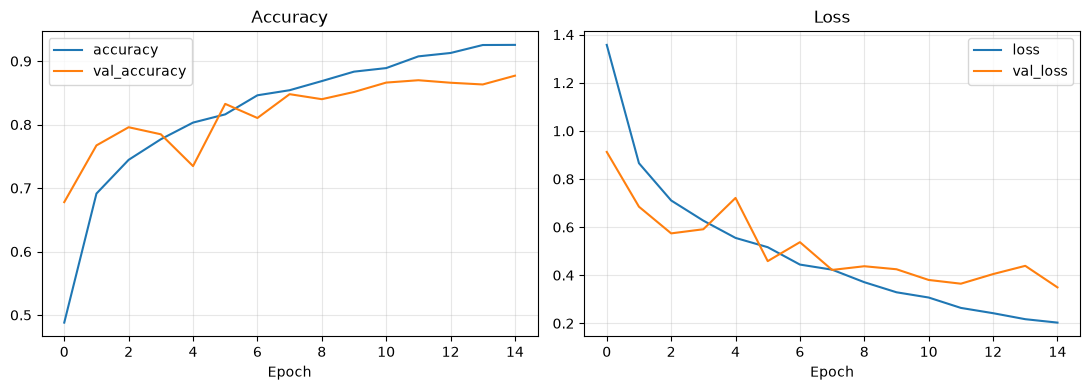

Final train accuracy 0.926, validation 0.877, gap 0.049


In [6]:
h = pd.DataFrame(history.history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
h[["accuracy", "val_accuracy"]].plot(ax=axes[0], title="Accuracy", xlabel="Epoch")
h[["loss", "val_loss"]].plot(ax=axes[1], title="Loss", xlabel="Epoch")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(FIGURES_DIR / "baseline_curves.png", dpi=150); plt.show()
gap = h["accuracy"].iloc[-1] - h["val_accuracy"].iloc[-1]
print(f"Final train accuracy {h['accuracy'].iloc[-1]:.3f}, validation {h['val_accuracy'].iloc[-1]:.3f}, gap {gap:.3f}")

## 📝 Observations
*Fill in after training:*
- Best validation accuracy: …
- Does the training accuracy pull away from the validation accuracy? From which epoch? What does that mean?
- Ideas for improvement (they motivate Step 3): …